# XSE2016CAV: under-approximation of backward reachable sets by polytopes

Xue, B., She, Z., & Easwaran, A. (2016). Under-approximating backward reachable sets by polytopes. *CAV 2016*, pp. 457-476.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ASAG-ISCAS/PyBDR/blob/master/examples/xse2016cav.ipynb)

Each case is independent. Some cases run for several minutes; the outputs stored in this notebook show the results without running it.

In [1]:
# install PyBDR when running on Colab (skipped when it is already installed)
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pybdr") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                           "pybdr @ git+https://github.com/ASAG-ISCAS/PyBDR"])

In [2]:
%matplotlib inline

import numpy as np
from pybdr.algorithm import XSE2016CAV, ASB2008CDC
from pybdr.dynamic_system import NonLinSys
from pybdr.geometry import Interval, Zonotope
from pybdr.model import *
from pybdr.util.visualization import plot

## Case 00

model `synchronous_machine`, `t_end = 2`, `step = 0.3`

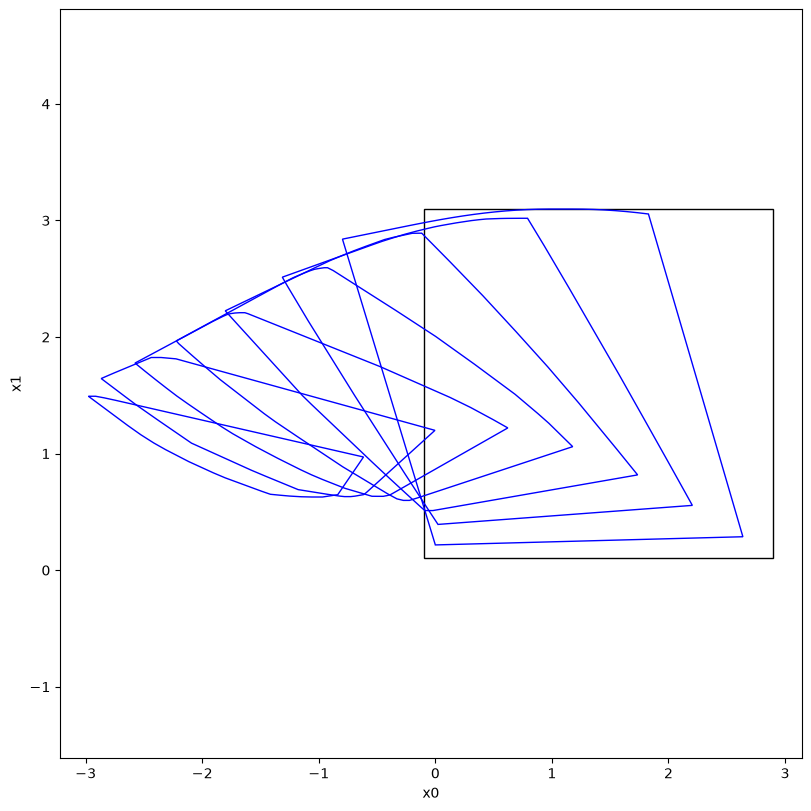

(<Figure size 800x800 with 1 Axes>, <Axes: xlabel='x0', ylabel='x1'>)

In [3]:
options = XSE2016CAV.Options()
options.t_end = 2
options.step = 0.3
options.r0 = Interval([-0.1, 0.1], [2.9, 3.1])
options.epsilon = 0.5
options.epsilon_m = 0.1

# settings for one step backward over approximation computation
options_back_one_step = ASB2008CDC.Options()
options_back_one_step.t_end = options.step
options_back_one_step.step = options.step / 3
options_back_one_step.tensor_order = 2
options_back_one_step.taylor_terms = 4
options_back_one_step.u = Zonotope.zero(1, 1)
options_back_one_step.u_trans = np.zeros(1)

# settings for the using geometry
Zonotope.REDUCE_METHOD = Zonotope.REDUCE_METHOD.GIRARD
Zonotope.ORDER = 50

# reachable sets computation
rs, _ = XSE2016CAV.reach(synchronous_machine, [2, 1], options, options_back_one_step)

# visualize the results
plot(rs, [0, 1])